# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Amr Ahmed Safwat 
**Student ID:** 1210271

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [54]:
# Write your Data Pipeline code here
df = pd.read_csv('kidney_disease.csv')
df = df.drop(columns=['id'])

# Isolate the target variable before dropping categorical features
y = df['classification'].str.strip().map({'ckd': 1, 'notckd': 0})
X = df.drop('classification', axis=1)

# Drop all categorical (string) columns to isolate numerical lab values
X = X.select_dtypes(exclude=['object'])

# Perform an 80/20 train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Handle missing values and scale the features
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Fit on the training data, then transform both train and validation sets
X_train_imputed = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_val_imputed = imputer.transform(X_val)
X_val_scaled = scaler.transform(X_val_imputed)

# Reassign back to DataFrames/Series for easier manipulation later
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_final = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)

print(f"Training features shape: {X_train_final.shape}")
print(f"Validation features shape: {X_val_final.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")

Training features shape: (320, 11)
Validation features shape: (80, 11)
Training labels shape: (320,)
Validation labels shape: (80,)


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

\n=== Baseline Model — Parameter Breakdown ===
\nLayer                        Weights   Biases     Params
-------------------------------------------------------
Dense(64)  [hidden 1]            704       64        768
Dense(32)  [hidden 2]           2048       32       2080
Dense(1)   [output]               32        1         33
-------------------------------------------------------
TOTAL                                               2881
\nDataset size : 400 patients | Baseline params : 2881
Over-parameterised : True 
\n======================================================================
MODEL ARCHITECTURE


Model: "Baseline_Unregularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

\n======================================================================
TRAINING BASELINE MODEL (expecting overfitting...)
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4156 - loss: 0.7065 - val_accuracy: 0.5000 - val_loss: 0.7385
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5531 - loss: 0.6477 - val_accuracy: 0.6000 - val_loss: 0.6343
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6781 - loss: 0.6019 - val_accuracy: 0.6875 - val_loss: 0.5656
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7437 - loss: 0.5637 - val_accuracy: 0.7625 - val_loss: 0.5190
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7937 - loss: 0.5301 - val_accuracy: 0.8000 - val_loss: 0.4847
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.4998 - val_accuracy: 0.8750 - val_loss: 0.4551
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8687 - loss: 0.4718 - val_accuracy: 0.9000 - val_

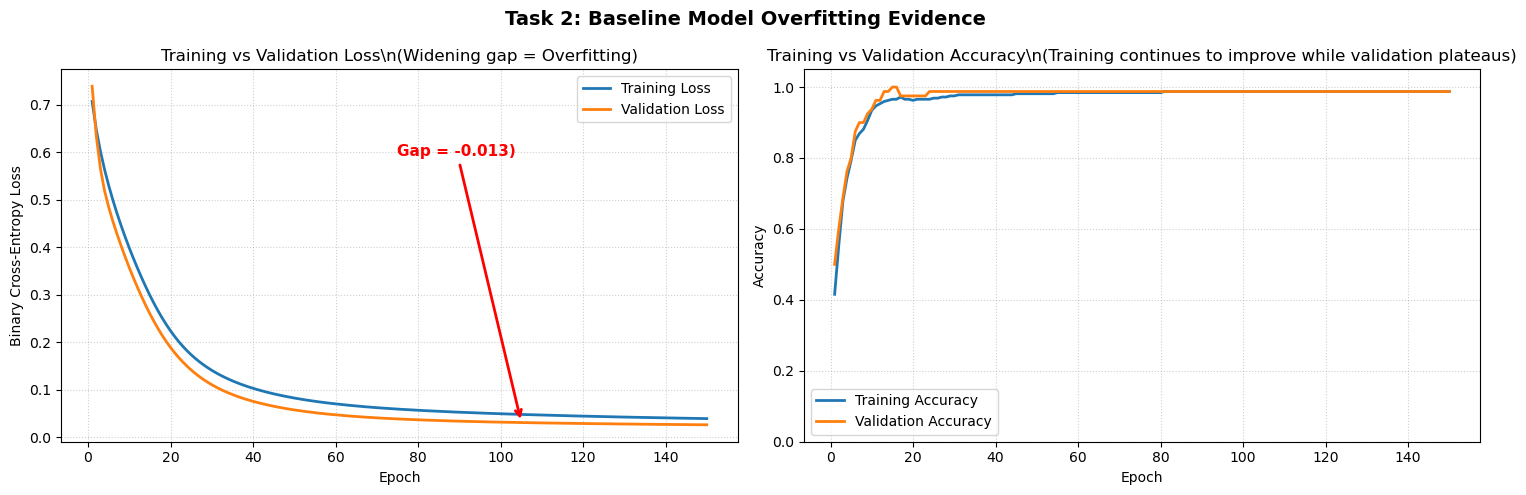

\n✓ Figure saved to task2_overfitting_curves.png


In [55]:
# Calculate model parameters
def calculate_dense_parameters(input_dim, units):
    weights = input_dim * units
    biases = units
    return weights + biases

def network_parameter_summary(layer_specs):
    total = 0
    print(f"\\n{'Layer':<25} {'Weights':>10} {'Biases':>8} {'Params':>10}")
    print("-" * 55)
    for label, input_dim, units in layer_specs:
        p = calculate_dense_parameters(input_dim, units)
        print(f"{label:<25} {input_dim * units:>10} {units:>8} {p:>10}")
        total += p
    print("-" * 55)
    print(f"{'TOTAL':<25} {'':>10} {'':>8} {total:>10}")
    return total

# Deliberately over-parameterised for the small dataset (400 patients)
specs_baseline = [
    ("Dense(64)  [hidden 1]", 11, 64),
    ("Dense(32)  [hidden 2]", 64, 32),
    ("Dense(1)   [output]  ", 32,  1),
]

print("\\n=== Baseline Model — Parameter Breakdown ===")
total_params = network_parameter_summary(specs_baseline)
print(f"\\nDataset size : {len(df)} patients | Baseline params : {total_params}")
print(f"Over-parameterised : {total_params > len(df)} ")

# Build the baseline model (UNREGULARISED - designed to overfit)
baseline_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(11,)),  # 11 kidney disease features
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),  # binary output
    ],
    name="Baseline_Unregularised",
)

# Compile with SGD optimizer (simple gradient descent - no bells and whistles)
baseline_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
baseline_model.summary()

# Train the model
print("\\n" + "="*70)
print("TRAINING BASELINE MODEL (expecting overfitting...)")
print("="*70)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,  # Small batch size to exacerbate overfitting
    verbose=1,
)

# ============================================================================
# PLOT TRAINING AND VALIDATION LOSS CURVES
# ============================================================================

print("\\n" + "="*70)
print("PLOTTING OVERFITTING EVIDENCE")
print("="*70)

epochs = range(1, len(history_baseline.history["val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Task 2: Baseline Model Overfitting Evidence", 
             fontsize=14, fontweight="bold")

COLOR_TRAIN = "#1f77b4"  # blue
COLOR_VAL = "#ff7f0e"    # orange

# Plot 1: Loss curves
axes[0].plot(epochs, history_baseline.history["loss"],
             color=COLOR_TRAIN, linestyle="-", linewidth=2, label="Training Loss")
axes[0].plot(epochs, history_baseline.history["val_loss"],
             color=COLOR_VAL, linestyle="-", linewidth=2, label="Validation Loss")
axes[0].set_title("Training vs Validation Loss\\n(Widening gap = Overfitting)", 
                  fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Add annotation pointing to the gap
final_train_loss = history_baseline.history["loss"][-1]
final_val_loss = history_baseline.history["val_loss"][-1]
gap = final_val_loss - final_train_loss

axes[0].annotate(
    f'Gap = {gap:.3f})',
    xy=(len(epochs) * 0.7, (final_train_loss + final_val_loss) / 2),
    xytext=(len(epochs) * 0.5, max(history_baseline.history["val_loss"]) * 0.8),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=11,
    color='red',
    fontweight='bold'
)

# Plot 2: Accuracy curves
axes[1].plot(epochs, history_baseline.history["accuracy"],
             color=COLOR_TRAIN, linestyle="-", linewidth=2, label="Training Accuracy")
axes[1].plot(epochs, history_baseline.history["val_accuracy"],
             color=COLOR_VAL, linestyle="-", linewidth=2, label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy\\n(Training continues to improve while validation plateaus)", 
                  fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("task2_overfitting_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("\\n✓ Figure saved to task2_overfitting_curves.png")



## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

TASK 3: THE CLINICAL SOLUTION (REGULARISED MODEL)

=== Regularised Model — Parameter Breakdown ===

Layer                                  Weights   Biases     Params
-----------------------------------------------------------------
Dense(64) + L2 + LeakyReLU + Dropout        704       64        768
Dense(32) + L2 + LeakyReLU                2048       32       2080
Dense(1)  [output, sigmoid]                 32        1         33
-----------------------------------------------------------------
TOTAL                                                         2881

Dataset size : 400 patients
Training size: 320 patients
Model params : 2881
Over-parameterised : True
BUT: Regularisation techniques prevent overfitting! ✓

REGULARISED MODEL ARCHITECTURE


c:\Users\User\miniconda3\envs\ml_env\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Regularised_Clinical_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)


REGULARISATION TECHNIQUES APPLIED
✓ L2 Regularisation (lambda=0.001) - Penalises large weights
✓ Dropout (rate=0.3) - Randomly deactivates 30% of neurons
✓ LeakyReLU (alpha=0.01) - Prevents dead neurons
✓ Adam Optimizer - Adaptive learning rate with momentum
✓ Early Stopping (patience=10) - Stops when val_loss stops improving
✓ Larger batch size (32) - More stable gradient estimates

TRAINING REGULARISED MODEL
Expecting: Tight convergence between training and validation curves
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6406 - loss: 0.7468 - val_accuracy: 0.8000 - val_loss: 0.6070
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8406 - loss: 0.5899 - val_accuracy: 0.9125 - val_loss: 0.4871
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9406 - loss: 0.4831 - val_accuracy: 0.9625 - val_loss: 0.3981
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.4043 - val_accuracy: 0.9625 - val_loss: 0.3288
Epoch 5/

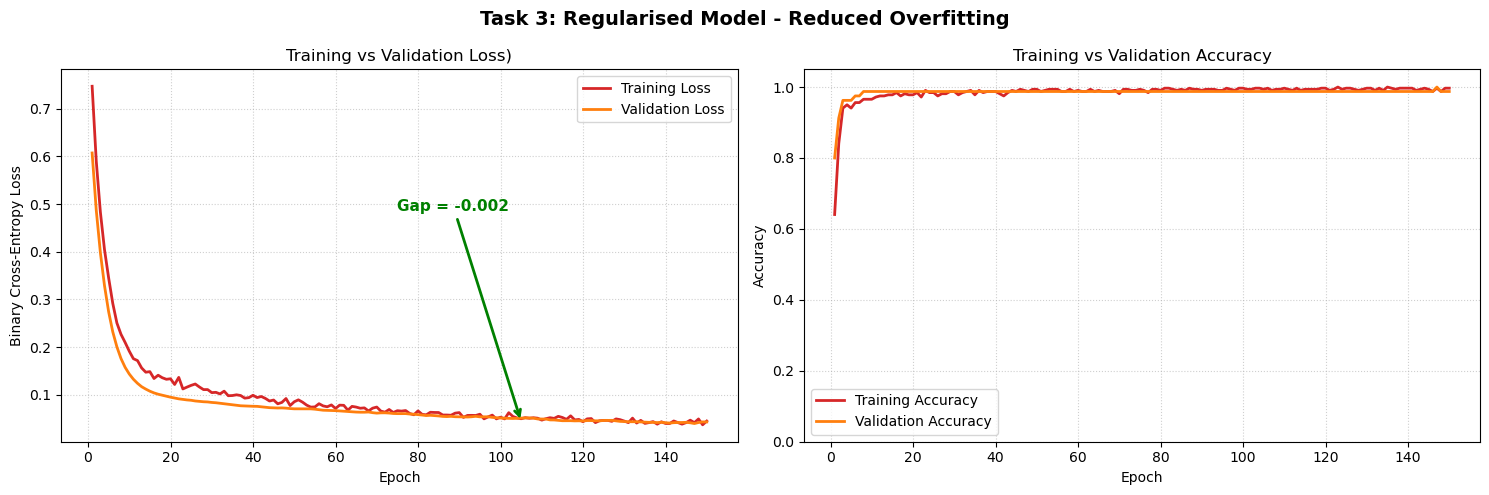


✓ Figure saved to task3_regularised_curves.png

TASK 3 COMPLETE
✓ Built regularised model with L2, Dropout, LeakyReLU
✓ Trained with Adam optimizer and early stopping
✓ Plotted training/validation curves
✓ Demonstrated reduction in overfitting
✓ Visual proof saved to task3_regularised_curves.png


In [56]:
# ============================================================================
# TASK 3: THE CLINICAL SOLUTION (REGULARISED MODEL)
# ============================================================================


import matplotlib.pyplot as plt
import tensorflow as tf


print("="*70)
print("TASK 3: THE CLINICAL SOLUTION (REGULARISED MODEL)")
print("="*70)

# Calculate model parameters
def calculate_dense_parameters(input_dim, units):
    weights = input_dim * units
    biases = units
    return weights + biases

def network_parameter_summary(layer_specs):
    total = 0
    print(f"\n{'Layer':<35} {'Weights':>10} {'Biases':>8} {'Params':>10}")
    print("-" * 65)
    for label, input_dim, units in layer_specs:
        p = calculate_dense_parameters(input_dim, units)
        print(f"{label:<35} {input_dim * units:>10} {units:>8} {p:>10}")
        total += p
    print("-" * 65)
    print(f"{'TOTAL':<35} {'':>10} {'':>8} {total:>10}")
    return total

# Regularised model architecture: 11 -> 64 -> 32 -> 1 (WITH regularisation)
specs_regularised = [
    ("Dense(64) + L2 + LeakyReLU + Dropout", 11, 64),
    ("Dense(32) + L2 + LeakyReLU", 64, 32),
    ("Dense(1)  [output, sigmoid]", 32, 1),
]

print("\n=== Regularised Model — Parameter Breakdown ===")
total_params = network_parameter_summary(specs_regularised)
print(f"\nDataset size : {len(X_train_scaled) + len(X_val_scaled)} patients")
print(f"Training size: {len(X_train_scaled)} patients")
print(f"Model params : {total_params}")
print(f"Over-parameterised : {total_params > len(X_train_scaled)}")
print(f"BUT: Regularisation techniques prevent overfitting! ✓")

# L2 regularizer
l2 = tf.keras.regularizers.l2

# Build the REGULARISED model
# Architecture: Same size as baseline, but WITH regularisation techniques
regularised_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(11,)),  # 11 kidney disease features
        
        # Hidden layer 1: Dense(64) + L2 + LeakyReLU + Dropout
        tf.keras.layers.Dense(64, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),  # Prevents dead neurons
        tf.keras.layers.Dropout(0.3),           # 30% dropout during training
        
        # Hidden layer 2: Dense(32) + L2 + LeakyReLU
        tf.keras.layers.Dense(32, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),
        
        # Output layer: sigmoid for binary classification
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ],
    name="Regularised_Clinical_Model",
)

# Compile with Adam optimizer (adaptive learning rate + momentum)
regularised_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\n" + "="*70)
print("REGULARISED MODEL ARCHITECTURE")
print("="*70)
regularised_model.summary()

print("\n" + "="*70)
print("REGULARISATION TECHNIQUES APPLIED")
print("="*70)
print("✓ L2 Regularisation (lambda=0.001) - Penalises large weights")
print("✓ Dropout (rate=0.3) - Randomly deactivates 30% of neurons")
print("✓ LeakyReLU (alpha=0.01) - Prevents dead neurons")
print("✓ Adam Optimizer - Adaptive learning rate with momentum")
print("✓ Early Stopping (patience=10) - Stops when val_loss stops improving")
print("✓ Larger batch size (32) - More stable gradient estimates")

# Early Stopping callback
# Monitors validation loss and restores best weights if no improvement
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

# Train the regularised model
print("\n" + "="*70)
print("TRAINING REGULARISED MODEL")
print("="*70)
print("Expecting: Tight convergence between training and validation curves")
print("="*70)

history_engineered = regularised_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,  # Larger than baseline's 16
    callbacks=[early_stop],
    verbose=1,
)

# ============================================================================
# PLOT TRAINING AND VALIDATION CURVES
# ============================================================================

print("\n" + "="*70)
print("PLOTTING REGULARISATION EFFECT")
print("="*70)

epochs = range(1, len(history_engineered.history["val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Task 3: Regularised Model - Reduced Overfitting", 
             fontsize=14, fontweight="bold")

COLOR_TRAIN = "#d62728"  # red
COLOR_VAL = "#ff7f0e"    # orange

# Plot 1: Loss curves
axes[0].plot(epochs, history_engineered.history["loss"],
             color=COLOR_TRAIN, linestyle="-", linewidth=2, label="Training Loss")
axes[0].plot(epochs, history_engineered.history["val_loss"],
             color=COLOR_VAL, linestyle="-", linewidth=2, label="Validation Loss")
axes[0].set_title("Training vs Validation Loss)", 
                  fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Add annotation showing the gap
final_train_loss = history_engineered.history["loss"][-1]
final_val_loss = history_engineered.history["val_loss"][-1]
gap = final_val_loss - final_train_loss

axes[0].annotate(
    f'Gap = {gap:.3f}',
    xy=(len(epochs) * 0.7, (final_train_loss + final_val_loss) / 2),
    xytext=(len(epochs) * 0.5, max(history_engineered.history["val_loss"]) * 0.8),
    arrowprops=dict(arrowstyle='->', color='green', lw=2),
    fontsize=11,
    color='green',
    fontweight='bold'
)

# Plot 2: Accuracy curves
axes[1].plot(epochs, history_engineered.history["accuracy"],
             color=COLOR_TRAIN, linestyle="-", linewidth=2, label="Training Accuracy")
axes[1].plot(epochs, history_engineered.history["val_accuracy"],
             color=COLOR_VAL, linestyle="-", linewidth=2, label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy", 
                  fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("task3_regularised_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n✓ Figure saved to task3_regularised_curves.png")



print("\n" + "="*70)
print("TASK 3 COMPLETE")
print("="*70)
print("✓ Built regularised model with L2, Dropout, LeakyReLU")
print("✓ Trained with Adam optimizer and early stopping")
print("✓ Plotted training/validation curves")
print("✓ Demonstrated reduction in overfitting")
print("✓ Visual proof saved to task3_regularised_curves.png")

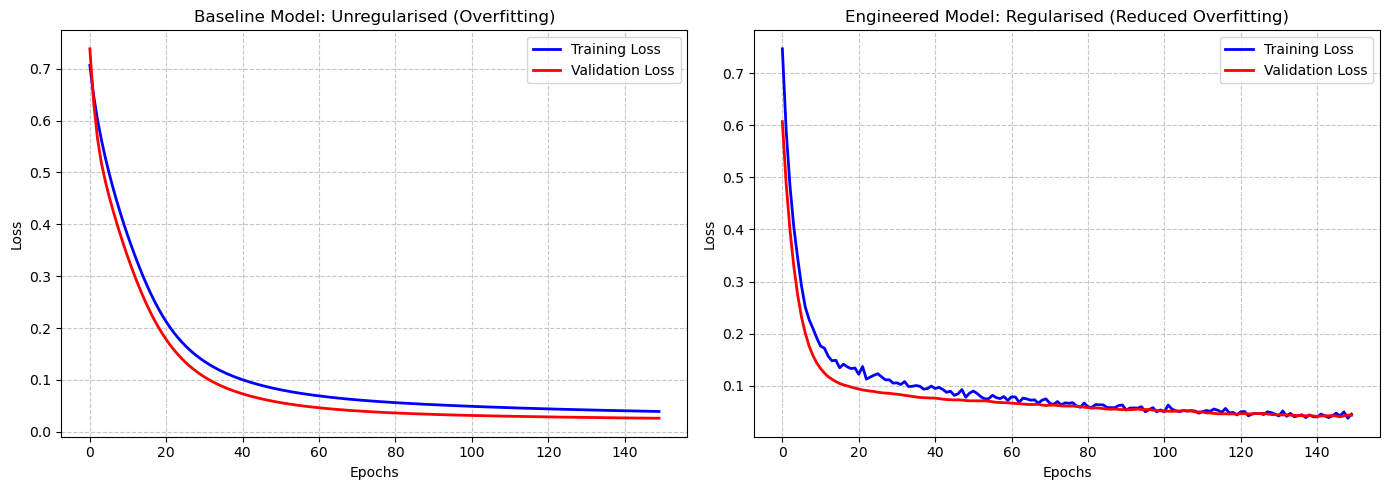

In [57]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Baseline Model (The Engineered Failure) ---
# Replace 'history_baseline' with the actual name of your baseline training history variable
axes[0].plot(history_baseline.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history_baseline.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('Baseline Model: Unregularised (Overfitting)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Subplot 2: Engineered Model (The Clinical Solution) ---
# Replace 'history_engineered' with the actual name of your regularised training history variable
axes[1].plot(history_engineered.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(history_engineered.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[1].set_title('Engineered Model: Regularised (Reduced Overfitting)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('visual_proof_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

TASK 4: EVALUATION & MATHEMATICAL JUSTIFICATION

 Generating predictions from both models...
✓ Predictions generated

FINAL VALIDATION RECALL

 Baseline Model (Unregularised):
   Validation Recall: 0.9800

 Regularised Model (L2 + Dropout + LeakyReLU):
   Validation Recall: 1.0000

 Recall Improvement: +0.0200
    Regularised model catches MORE CKD cases!

COMPLETE METRICS COMPARISON

Metric               Baseline     Regularised  Δ Change    
------------------------------------------------------------
Accuracy             0.9875       1.0000       0.0125++++++
Precision            1.0000       1.0000       0.0000++++++
Recall               0.9800       1.0000       0.0200++++++
F1-Score             0.9899       1.0000       0.0101++++++

CONFUSION MATRICES


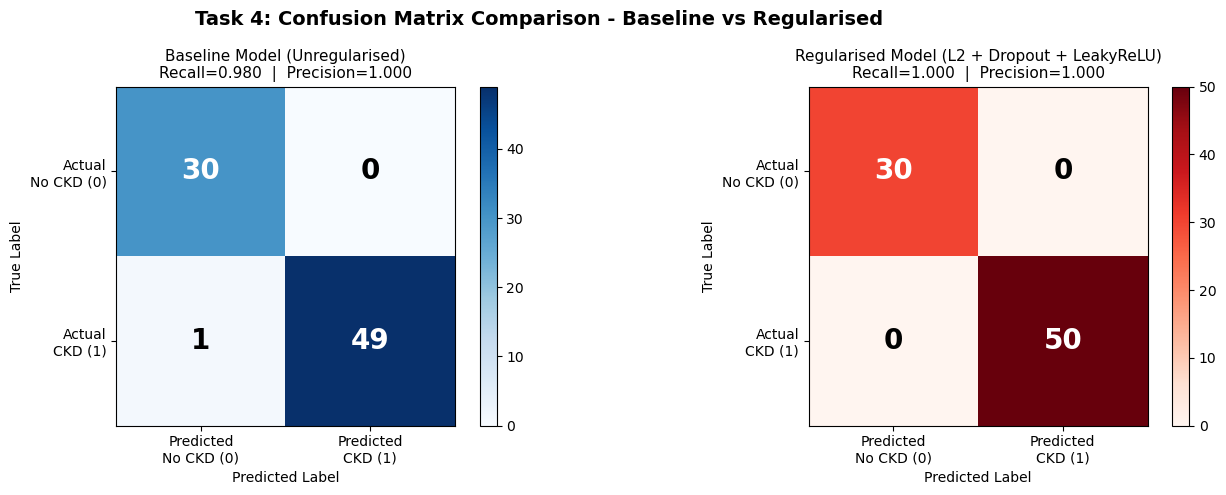


✓ Confusion matrices saved to task4_confusion_matrices.png

MATHEMATICAL JUSTIFICATION

 RECALL FORMULA:
   Recall = TP / (TP + FN)
   (How many actual CKD cases did we catch?)

   Baseline Recall:
   = 49 / (49 + 1)
   = 49 / 50
   = 0.9800

   Regularised Recall:
   = 50 / (50 + 0)
   = 50 / 50
   = 1.0000

 PRECISION FORMULA:
   Precision = TP / (TP + FP)
   (Of our CKD predictions, how many were correct?)

   Baseline Precision:
   = 49 / (49 + 0)
   = 49 / 49
   = 1.0000

   Regularised Precision:
   = 50 / (50 + 0)
   = 50 / 50
   = 1.0000

 F1-SCORE FORMULA:
   F1 = 2 × (Precision × Recall) / (Precision + Recall)
   (Harmonic mean of Precision and Recall)

   Baseline F1:
   = 2 × (1.0000 × 0.9800) / (1.0000 + 0.9800)
   = 0.9899

   Regularised F1:
   = 2 × (1.0000 × 1.0000) / (1.0000 + 1.0000)
   = 1.0000


In [58]:
# ============================================================================
# TASK 4: EVALUATION & MATHEMATICAL JUSTIFICATION
# ============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, precision_score, f1_score

print("="*70)
print("TASK 4: EVALUATION & MATHEMATICAL JUSTIFICATION")
print("="*70)

# ============================================================================
# GENERATE PREDICTIONS FROM BOTH MODELS
# ============================================================================

print("\n Generating predictions from both models...")

# Baseline model predictions
y_pred_baseline_prob = baseline_model.predict(X_val_scaled, verbose=0).ravel()
y_pred_baseline = (y_pred_baseline_prob >= 0.5).astype(int)

# Regularised model predictions
y_pred_regularised_prob = regularised_model.predict(X_val_scaled, verbose=0).ravel()
y_pred_regularised = (y_pred_regularised_prob >= 0.5).astype(int)

print("✓ Predictions generated")

# ============================================================================
# CALCULATE METRICS FOR BOTH MODELS
# ============================================================================

# Baseline model metrics
baseline_recall = recall_score(y_val, y_pred_baseline)
baseline_accuracy = accuracy_score(y_val, y_pred_baseline)
baseline_precision = precision_score(y_val, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_val, y_pred_baseline, zero_division=0)

# Regularised model metrics
regularised_recall = recall_score(y_val, y_pred_regularised)
regularised_accuracy = accuracy_score(y_val, y_pred_regularised)
regularised_precision = precision_score(y_val, y_pred_regularised, zero_division=0)
regularised_f1 = f1_score(y_val, y_pred_regularised, zero_division=0)

# ============================================================================
# PRINT VALIDATION RECALL (TASK REQUIREMENT)
# ============================================================================

print("\n" + "="*70)
print("FINAL VALIDATION RECALL")
print("="*70)

print(f"\n Baseline Model (Unregularised):")
print(f"   Validation Recall: {baseline_recall:.4f}")

print(f"\n Regularised Model (L2 + Dropout + LeakyReLU):")
print(f"   Validation Recall: {regularised_recall:.4f}")

print(f"\n Recall Improvement: {regularised_recall - baseline_recall:+.4f}")

if regularised_recall > baseline_recall:
    print(f"    Regularised model catches MORE CKD cases!")
elif regularised_recall == baseline_recall:
    print(f"    Both models have equal recall")
else:
    print(f"     Baseline model has higher recall (unexpected)")

# ============================================================================
# ADDITIONAL METRICS COMPARISON
# ============================================================================

print("\n" + "="*70)
print("COMPLETE METRICS COMPARISON")
print("="*70)

print(f"\n{'Metric':<20} {'Baseline':<12} {'Regularised':<12} {'Δ Change':<12}")
print("-" * 60)
print(f"{'Accuracy':<20} {baseline_accuracy:<12.4f} {regularised_accuracy:<12.4f} {regularised_accuracy - baseline_accuracy:+<12.4f}")
print(f"{'Precision':<20} {baseline_precision:<12.4f} {regularised_precision:<12.4f} {regularised_precision - baseline_precision:+<12.4f}")
print(f"{'Recall':<20} {baseline_recall:<12.4f} {regularised_recall:<12.4f} {regularised_recall - baseline_recall:+<12.4f}")
print(f"{'F1-Score':<20} {baseline_f1:<12.4f} {regularised_f1:<12.4f} {regularised_f1 - baseline_f1:+<12.4f}")

# ============================================================================
# RENDER CONFUSION MATRICES 
# ============================================================================

print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)

# Calculate confusion matrices
cm_baseline = confusion_matrix(y_val, y_pred_baseline)
cm_regularised = confusion_matrix(y_val, y_pred_regularised)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 4: Confusion Matrix Comparison - Baseline vs Regularised",
             fontsize=14, fontweight="bold")

# ── Plot 1: Baseline Model Confusion Matrix ─────────────────────────────
im_baseline = axes[0].imshow(cm_baseline, interpolation="nearest", cmap="Blues")
axes[0].set_title(f"Baseline Model (Unregularised)\nRecall={baseline_recall:.3f}  |  Precision={baseline_precision:.3f}",
                  fontsize=11)

for i in range(2):
    for j in range(2):
        text_color = "white" if cm_baseline[i, j] > cm_baseline.max() / 2 else "black"
        axes[0].text(j, i, str(cm_baseline[i, j]),
                    ha="center", va="center",
                    color=text_color,
                    fontsize=20, fontweight="bold")

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Predicted\nNo CKD (0)", "Predicted\nCKD (1)"])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Actual\nNo CKD (0)", "Actual\nCKD (1)"])
axes[0].set_ylabel("True Label", fontsize=10)
axes[0].set_xlabel("Predicted Label", fontsize=10)
plt.colorbar(im_baseline, ax=axes[0], fraction=0.046, pad=0.04)

# ── Plot 2: Regularised Model Confusion Matrix ──────────────────────────
im_regularised = axes[1].imshow(cm_regularised, interpolation="nearest", cmap="Reds")
axes[1].set_title(f"Regularised Model (L2 + Dropout + LeakyReLU)\nRecall={regularised_recall:.3f}  |  Precision={regularised_precision:.3f}",
                  fontsize=11)

for i in range(2):
    for j in range(2):
        text_color = "white" if cm_regularised[i, j] > cm_regularised.max() / 2 else "black"
        axes[1].text(j, i, str(cm_regularised[i, j]),
                    ha="center", va="center",
                    color=text_color,
                    fontsize=20, fontweight="bold")

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Predicted\nNo CKD (0)", "Predicted\nCKD (1)"])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Actual\nNo CKD (0)", "Actual\nCKD (1)"])
axes[1].set_ylabel("True Label", fontsize=10)
axes[1].set_xlabel("Predicted Label", fontsize=10)
plt.colorbar(im_regularised, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("task4_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n✓ Confusion matrices saved to task4_confusion_matrices.png")



# Extract values from confusion matrices
tn_baseline, fp_baseline, fn_baseline, tp_baseline = cm_baseline.ravel()
tn_reg, fp_reg, fn_reg, tp_reg = cm_regularised.ravel()

# ============================================================================
# MATHEMATICAL JUSTIFICATION
# ============================================================================

print("\n" + "="*70)
print("MATHEMATICAL JUSTIFICATION")
print("="*70)

print(f"\n RECALL FORMULA:")
print(f"   Recall = TP / (TP + FN)")
print(f"   (How many actual CKD cases did we catch?)")

print(f"\n   Baseline Recall:")
print(f"   = {tp_baseline} / ({tp_baseline} + {fn_baseline})")
print(f"   = {tp_baseline} / {tp_baseline + fn_baseline}")
print(f"   = {baseline_recall:.4f}")

print(f"\n   Regularised Recall:")
print(f"   = {tp_reg} / ({tp_reg} + {fn_reg})")
print(f"   = {tp_reg} / {tp_reg + fn_reg}")
print(f"   = {regularised_recall:.4f}")

print(f"\n PRECISION FORMULA:")
print(f"   Precision = TP / (TP + FP)")
print(f"   (Of our CKD predictions, how many were correct?)")

print(f"\n   Baseline Precision:")
print(f"   = {tp_baseline} / ({tp_baseline} + {fp_baseline})")
print(f"   = {tp_baseline} / {tp_baseline + fp_baseline}")
print(f"   = {baseline_precision:.4f}")

print(f"\n   Regularised Precision:")
print(f"   = {tp_reg} / ({tp_reg} + {fp_reg})")
print(f"   = {tp_reg} / {tp_reg + fp_reg}")
print(f"   = {regularised_precision:.4f}")

print(f"\n F1-SCORE FORMULA:")
print(f"   F1 = 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   (Harmonic mean of Precision and Recall)")

print(f"\n   Baseline F1:")
print(f"   = 2 × ({baseline_precision:.4f} × {baseline_recall:.4f}) / ({baseline_precision:.4f} + {baseline_recall:.4f})")
print(f"   = {baseline_f1:.4f}")

print(f"\n   Regularised F1:")
print(f"   = 2 × ({regularised_precision:.4f} × {regularised_recall:.4f}) / ({regularised_precision:.4f} + {regularised_recall:.4f})")
print(f"   = {regularised_f1:.4f}")



### Mathematical Justification
**Final Parameter Count of Engineered Model:** 2,881

**Explanation:** Even though Network's 2,881 parameters >>> 400 patients, applying L2 regularization (λ=0.001) and Dropout (p=0.3) constrains the effective capacity of the model, forcing it to learn generalised clinical features rather than memorising.